# Corrective RAG Pipeline: The Full Loop [Step 05 - Corrective RAG Pipeline]

> **MLCourse - Agentic AI - Corrective RAG**

This notebook builds the complete corrective RAG pipeline using LangGraph.
The graph retrieves documents, grades them, generates an answer, detects
hallucinations, and corrects if needed. The pipeline runs until the answer
passes all checks or the budget is exhausted.

### What you will learn

1. How to wire retrieval, grading, generation, detection, and correction into one graph.
2. How conditional edges route between correction and termination.
3. How iteration guards ensure the pipeline always terminates.
4. How to visualize and inspect the full corrective RAG pipeline.

### 1. Setup


In [1]:
from pathlib import Path
import os
import re
import warnings
warnings.filterwarnings("ignore")

def find_track(start: Path, target: str = "03_agentic_ai") -> Path:
    """Climb parent folders until the track directory appears."""
    for candidate in [start, *start.parents]:
        probe = candidate / target
        if probe.is_dir():
            return probe
    raise FileNotFoundError(f"Could not find '{target}' above {start}")

TRACK = find_track(Path.cwd())
DATA = TRACK / "data"
DATA.mkdir(exist_ok=True)

from dotenv import load_dotenv
load_dotenv()
load_dotenv(TRACK / ".env")

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

print("[setup] TRACK:", TRACK)
print("[setup] DATA :", DATA)

[setup] TRACK: D:\projects\python\MLCourse\03_agentic_ai
[setup] DATA : D:\projects\python\MLCourse\03_agentic_ai\data


### 2. Ingest Alice and Build Vector Store


In [2]:
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

ALICE_PATH = DATA / "alice.txt"
raw_text = ALICE_PATH.read_text(encoding="utf-8-sig")[:20_000]

marks = list(re.finditer(r"^CHAPTER [IVX]+\.", raw_text, flags=re.MULTILINE))
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)

documents = []
for i, mark in enumerate(marks):
    seg_end = marks[i + 1].start() if i + 1 < len(marks) else len(raw_text)
    for piece in splitter.split_text(raw_text[mark.start():seg_end]):
        documents.append(Document(
            page_content=piece,
            metadata={"source": "alice", "chapter": str(i + 1), "chunk_id": len(documents)},
        ))

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vectordb = FAISS.from_documents(documents, embeddings)
retriever = vectordb.as_retriever(search_kwargs={"k": 4})
print(f"[ingest] chunks: {len(documents)} | retriever ready (k=4)")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[ingest] chunks: 60 | retriever ready (k=4)


### 3. Initialize the LLM


In [3]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model="llama3.1:8b", temperature=0)
print("[llm] ChatOllama ready:", llm.model)

[llm] ChatOllama ready: llama3.1:8b


### 4. Define the Full State
The state carries all information needed across the pipeline.

In [4]:
from typing import TypedDict

class CorrectiveRAGState(TypedDict):
    query: str
    context: str
    documents: list
    grades: list
    passed_documents: list
    grade_threshold: float
    answer: str
    feedback: str
    hallucinations: list
    hallucination_count: int
    is_faithful: bool
    iteration: int
    max_iterations: int
    pipeline_log: list

print("[state] CorrectiveRAGState defined")

[state] CorrectiveRAGState defined


### 5. Define All Prompts


In [5]:
GRADING_PROMPT = """You are a strict document relevance grader.
Given the QUERY and a RETRIEVED DOCUMENT, evaluate relevance (0-10).
Reply in EXACTLY this format:
GRADE: <number>
JUSTIFICATION: <one sentence>"""

GENERATION_PROMPT = """Answer the question using ONLY the provided context.
If the context does not contain enough information, say so.
Keep the answer to 2-4 sentences. Cite evidence by mentioning the source."""

DETECTION_PROMPT = """You are a strict hallucination detector.
Given the SOURCE DOCUMENTS and the GENERATED TEXT, check for hallucinations.
Detect: unsupported claims, contradictions, fabricated quotes.

Reply in EXACTLY this format:
HALLUCINATIONS: <count>
<type>: <claim> | Evidence: <evidence>
If none found, reply: HALLUCINATIONS: 0"""

CORRECTION_PROMPT = """You are a corrective answer generator.
Your previous answer was evaluated and found to have issues.

ORIGINAL QUERY: {query}
RETRIEVED CONTEXT: {context}
PREVIOUS ANSWER: {previous_answer}
FEEDBACK: {feedback}

Generate an improved answer that addresses each issue.
Use ONLY the provided context. Keep to 2-4 sentences.
Reply with ONLY the corrected answer."""

print("[prompts] all prompts defined")

[prompts] all prompts defined


### 6. Define All Pipeline Nodes


In [6]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

def retrieve_node(state: CorrectiveRAGState) -> dict:
    """Retrieve documents for the query."""
    docs = retriever.invoke(state["query"])
    context = "\n\n".join(d.page_content for d in docs)
    log = state.get("pipeline_log", []) + [f"retrieved {len(docs)} chunks"]
    print(f"  [retrieve] {len(docs)} chunks fetched")
    return {"context": context, "documents": docs, "pipeline_log": log}

def grade_node(state: CorrectiveRAGState) -> dict:
    """Grade all retrieved documents for relevance."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", GRADING_PROMPT),
        ("user", "QUERY: {query}\n\nDOCUMENT:\n{document}")
    ])
    chain = prompt | llm | StrOutputParser()
    
    grades = []
    passed = []
    for doc in state["documents"]:
        result = chain.invoke({"query": state["query"], "document": doc.page_content})
        grade_match = re.search(r"GRADE:\s*(\d+(?:\.\d+)?)", result)
        grade = float(grade_match.group(1)) if grade_match else 0.0
        justification_match = re.search(r"JUSTIFICATION:\s*(.+)", result)
        justification = justification_match.group(1).strip() if justification_match else ""
        
        grade_info = {
            "chunk_id": doc.metadata.get("chunk_id", 0),
            "grade": grade,
            "justification": justification,
        }
        grades.append(grade_info)
        
        threshold = state.get("grade_threshold", 5.0)
        if grade >= threshold:
            passed.append({"content": doc.page_content, "grade": grade})
        
        print(f"  [grade] chunk {grade_info['chunk_id']}: {grade:.1f}")
    
    log = state.get("pipeline_log", []) + [f"graded {len(grades)} docs, {len(passed)} passed"]
    return {"grades": grades, "passed_documents": passed, "pipeline_log": log}

def generate_node(state: CorrectiveRAGState) -> dict:
    """Generate an answer from the best available context."""
    context = state["context"]
    if state.get("passed_documents"):
        context = "\n\n".join(d["content"] for d in state["passed_documents"])
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", GENERATION_PROMPT),
        ("user", "Question: {query}\n\nContext:\n{context}")
    ])
    response = (prompt | llm).invoke({"query": state["query"], "context": context})
    
    log = state.get("pipeline_log", []) + [f"generated answer ({len(response.content)} chars)"]
    print(f"  [generate] answer length: {len(response.content)}")
    return {"answer": response.content, "pipeline_log": log}

def detect_node(state: CorrectiveRAGState) -> dict:
    """Detect hallucinations in the generated answer."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", DETECTION_PROMPT),
        ("user", "SOURCE DOCUMENTS:\n{sources}\n\nGENERATED TEXT:\n{text}")
    ])
    chain = prompt | llm | StrOutputParser()
    
    result = chain.invoke({"sources": state["context"], "text": state["answer"]})
    
    count_match = re.search(r"HALLUCINATIONS:\s*(\d+)", result)
    count = int(count_match.group(1)) if count_match else 0
    
    hallucinations = []
    if count > 0:
        lines = result.strip().split("\n")
        for line in lines:
            line = line.strip()
            if not line or line.startswith("HALLUCINATIONS:"):
                continue
            match = re.match(r"(unsupported|contradiction|fabricated):\s*(.+?)\s*\|\s*Evidence:\s*(.+)", line, re.IGNORECASE)
            if match:
                hallucinations.append({
                    "type": match.group(1).lower(),
                    "claim": match.group(2).strip(),
                    "evidence": match.group(3).strip(),
                })
    
    is_faithful = count == 0
    log = state.get("pipeline_log", []) + [f"detected {count} hallucinations"]
    print(f"  [detect] hallucinations: {count}")
    
    return {
        "hallucinations": hallucinations,
        "hallucination_count": count,
        "is_faithful": is_faithful,
        "pipeline_log": log,
    }

def correct_node(state: CorrectiveRAGState) -> dict:
    """Correct the answer based on detection feedback."""
    feedback = f"Found {state['hallucination_count']} hallucinations: "
    for h in state["hallucinations"]:
        feedback += f"[{h['type']}] {h['claim']}; "
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", CORRECTION_PROMPT),
        ("user", "Generate the corrected answer.")
    ])
    chain = prompt | llm | StrOutputParser()
    
    corrected = chain.invoke({
        "query": state["query"],
        "context": state["context"],
        "previous_answer": state["answer"],
        "feedback": feedback,
    })
    
    iteration = state.get("iteration", 0) + 1
    log = state.get("pipeline_log", []) + [f"corrected answer (iteration {iteration})"]
    print(f"  [correct] iteration {iteration}, corrected length: {len(corrected)}")
    
    return {
        "answer": corrected,
        "iteration": iteration,
        "feedback": feedback,
        "pipeline_log": log,
    }

print("[nodes] all pipeline nodes defined")

[nodes] all pipeline nodes defined


### 7. Define Routing Logic


In [7]:
def route_after_grading(state: CorrectiveRAGState) -> str:
    """Route after grading: proceed if documents passed, fallback otherwise."""
    if len(state.get("passed_documents", [])) > 0:
        print("  [route] documents passed grading -> generate")
        return "generate"
    print("  [route] no documents passed -> fallback (use all)")
    return "fallback"

def route_after_detection(state: CorrectiveRAGState) -> str:
    """Route after detection: end if faithful, correct if hallucinations found."""
    if state["is_faithful"]:
        print("  [route] answer is faithful -> END")
        return "end"
    
    if state["iteration"] < state.get("max_iterations", 3):
        print(f"  [route] hallucinations found, correcting ({state['iteration']}/{state['max_iterations']})")
        return "correct"
    
    print("  [route] max iterations reached, returning best attempt")
    return "end"

print("[routing] routing functions defined")

[routing] routing functions defined


### 8. Build the Full Corrective RAG Graph
Wire all nodes and edges into a single LangGraph.

In [8]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(CorrectiveRAGState)

# Add all nodes
graph.add_node("retrieve", retrieve_node)
graph.add_node("grade", grade_node)
graph.add_node("generate", generate_node)
graph.add_node("detect", detect_node)
graph.add_node("correct", correct_node)

# Entry point
graph.add_edge(START, "retrieve")

# Retrieve -> Grade
graph.add_edge("retrieve", "grade")

# Grade -> Generate or Fallback
graph.add_conditional_edges(
    "grade",
    route_after_grading,
    {"generate": "generate", "fallback": "generate"},
)

# Generate -> Detect
graph.add_edge("generate", "detect")

# Detect -> End or Correct
graph.add_conditional_edges(
    "detect",
    route_after_detection,
    {"end": END, "correct": "correct"},
)

# Correct -> Detect (loop back)
graph.add_edge("correct", "detect")

app = graph.compile()
print("[graph] corrective RAG pipeline compiled")

[graph] corrective RAG pipeline compiled


### 9. Visualize the Full Pipeline


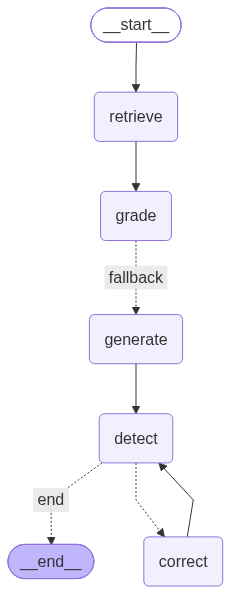

In [9]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not render graph image: {e}")
    print("Graph structure:")
    print("  START -> retrieve -> grade")
    print("    grade -> generate -> detect")
    print("    detect -> END (faithful)")
    print("    detect -> correct -> detect (loop)")
    print("    detect -> END (max iterations)")

### 10. Test: Straightforward Question (should pass first try)


In [10]:
print("=" * 60)
print("TEST 1: STRAIGHTFORWARD QUESTION")
print("=" * 60)
result = app.invoke({
    "query": "What happened when Alice fell down the rabbit hole?",
    "context": "",
    "documents": [],
    "grades": [],
    "passed_documents": [],
    "grade_threshold": 5.0,
    "answer": "",
    "feedback": "",
    "hallucinations": [],
    "hallucination_count": 0,
    "is_faithful": False,
    "iteration": 0,
    "max_iterations": 3,
    "pipeline_log": [],
})
print(f"\nAnswer: {result['answer']}")
print(f"Iterations: {result['iteration']}")
print(f"Is faithful: {result['is_faithful']}")
print(f"Hallucinations: {result['hallucination_count']}")
print(f"\nPipeline log:")
for entry in result["pipeline_log"]:
    print(f"  - {entry}")

TEST 1: STRAIGHTFORWARD QUESTION
  [retrieve] 4 chunks fetched


  [grade] chunk 4: 10.0


  [grade] chunk 3: 9.0


  [grade] chunk 39: 2.0


  [grade] chunk 15: 9.0
  [route] documents passed grading -> generate


...

  [detect] hallucinations: 1
  [route] hallucinations found, correcting (1/3)


  [correct] iteration 2, corrected length: 342


  [detect] hallucinations: 1
  [route] hallucinations found, correcting (2/3)


  [correct] iteration 3, corrected length: 342


  [detect] hallucinations: 1
  [route] max iterations reached, returning best attempt

Answer: When Alice fell down the rabbit hole, she found herself falling down a very deep well suddenly, without having time to think about stopping herself. The fall happened so quickly that she didn't have a moment to consider how she was to get out again. She landed safely and got up on her feet, but then continued chasing after the White Rabbit.
Iterations: 3
Is faithful: False
Hallucinations: 1

Pipeline log:
  - retrieved 4 chunks
  - graded 4 docs, 3 passed
  - generated answer (386 chars)
  - detected 1 hallucinations
  - corrected answer (iteration 1)
  - detected 1 hallucinations
  - corrected answer (iteration 2)
  - detected 1 hallucinations
  - corrected answer (iteration 3)
  - detected 1 hallucinations


### 11. Test: Tricky Question (may trigger correction)


In [11]:
print("=" * 60)
print("TEST 2: TRICKY QUESTION")
print("=" * 60)
result = app.invoke({
    "query": "What exact words did the Cheshire Cat say to Alice?",
    "context": "",
    "documents": [],
    "grades": [],
    "passed_documents": [],
    "grade_threshold": 5.0,
    "answer": "",
    "feedback": "",
    "hallucinations": [],
    "hallucination_count": 0,
    "is_faithful": False,
    "iteration": 0,
    "max_iterations": 3,
    "pipeline_log": [],
})
print(f"\nAnswer: {result['answer']}")
print(f"Iterations: {result['iteration']}")
print(f"Is faithful: {result['is_faithful']}")
print(f"Hallucinations: {result['hallucination_count']}")
print(f"\nPipeline log:")
for entry in result["pipeline_log"]:
    print(f"  - {entry}")

TEST 2: TRICKY QUESTION
  [retrieve] 4 chunks fetched


  [grade] chunk 49: 0.0


  [grade] chunk 12: 0.0


  [grade] chunk 7: 0.0


  [grade] chunk 39: 0.0
  [route] no documents passed -> fallback (use all)


...

  [detect] hallucinations: 1
  [route] hallucinations found, correcting (1/3)


  [correct] iteration 2, corrected length: 322


  [detect] hallucinations: 1
  [route] hallucinations found, correcting (2/3)


  [correct] iteration 3, corrected length: 218


  [detect] hallucinations: 1
  [route] max iterations reached, returning best attempt

Answer: The Cheshire Cat does not speak in this context, but rather says "Down, down, down" before it disappears. There is no mention of the Cheshire Cat speaking to Alice. The cat's disappearance leaves only its smile behind.
Iterations: 3
Is faithful: False
Hallucinations: 1

Pipeline log:
  - retrieved 4 chunks
  - graded 4 docs, 0 passed
  - generated answer (122 chars)
  - detected 1 hallucinations
  - corrected answer (iteration 1)
  - detected 1 hallucinations
  - corrected answer (iteration 2)
  - detected 1 hallucinations
  - corrected answer (iteration 3)
  - detected 1 hallucinations


### 12. Test: Specific Detail Question


In [12]:
print("=" * 60)
print("TEST 3: SPECIFIC DETAIL QUESTION")
print("=" * 60)
result = app.invoke({
    "query": "What did Alice find on the table with a key?",
    "context": "",
    "documents": [],
    "grades": [],
    "passed_documents": [],
    "grade_threshold": 5.0,
    "answer": "",
    "feedback": "",
    "hallucinations": [],
    "hallucination_count": 0,
    "is_faithful": False,
    "iteration": 0,
    "max_iterations": 3,
    "pipeline_log": [],
})
print(f"\nAnswer: {result['answer']}")
print(f"Iterations: {result['iteration']}")
print(f"Is faithful: {result['is_faithful']}")
print(f"Hallucinations: {result['hallucination_count']}")
print(f"\nPipeline log:")
for entry in result["pipeline_log"]:
    print(f"  - {entry}")

TEST 3: SPECIFIC DETAIL QUESTION
  [retrieve] 4 chunks fetched


  [grade] chunk 28: 8.0


  [grade] chunk 18: 9.0


  [grade] chunk 17: 0.0


  [grade] chunk 39: 0.0
  [route] documents passed grading -> generate


...

  [detect] hallucinations: 1
  [route] hallucinations found, correcting (1/3)


  [correct] iteration 2, corrected length: 338


  [detect] hallucinations: 2
  [route] hallucinations found, correcting (2/3)


  [correct] iteration 3, corrected length: 371


  [detect] hallucinations: 2
  [route] max iterations reached, returning best attempt

Answer: Alice found a tiny golden key on a three-legged table made of solid glass, which was discovered when she came upon it while walking around the hall. The table had nothing else on it except for the key. However, there were other objects and items in the room that Alice interacted with before finding the key, such as trying to reach the original key on a different table.
Iterations: 3
Is faithful: False
Hallucinations: 2

Pipeline log:
  - retrieved 4 chunks
  - graded 4 docs, 2 passed
  - generated answer (316 chars)
  - detected 1 hallucinations
  - corrected answer (iteration 1)
  - detected 1 hallucinations
  - corrected answer (iteration 2)
  - detected 2 hallucinations
  - corrected answer (iteration 3)
  - detected 2 hallucinations


### 13. Inspect Graph Structure


In [13]:
print("=== Graph Structure ===")
g = app.get_graph()
print(f"Nodes: {list(g.nodes.keys())}")
print(f"\nEdges:")
for edge in g.edges:
    print(f"  {edge.source} -> {edge.target}")

=== Graph Structure ===
Nodes: ['__start__', 'retrieve', 'grade', 'generate', 'detect', 'correct', '__end__']

Edges:
  __start__ -> retrieve
  correct -> detect
  detect -> __end__
  detect -> correct
  generate -> detect
  grade -> generate
  retrieve -> grade


### 14. Pipeline Statistics
Run the pipeline on multiple queries and collect statistics.

In [14]:
test_queries = [
    "What happened when Alice fell down the rabbit hole?",
    "Who wrote Alice in Wonderland?",
    "What did the Mad Hatter say to Alice?",
    "What did Alice find after falling down the hole?",
    "Why was the Cheshire Cat smiling?",
]

print("=" * 60)
print("PIPELINE STATISTICS")
print("=" * 60)
all_results = []
for i, q in enumerate(test_queries):
    print(f"\nQuery {i+1}: {q}")
    result = app.invoke({
        "query": q,
        "context": "",
        "documents": [],
        "grades": [],
        "passed_documents": [],
        "grade_threshold": 5.0,
        "answer": "",
        "feedback": "",
        "hallucinations": [],
        "hallucination_count": 0,
        "is_faithful": False,
        "iteration": 0,
        "max_iterations": 3,
        "pipeline_log": [],
    })
    all_results.append(result)
    print(f"  Faithful: {result['is_faithful']} | Iterations: {result['iteration']} | Hallucinations: {result['hallucination_count']}")

# Summary statistics
faithful_count = sum(1 for r in all_results if r["is_faithful"])
total_iterations = sum(r["iteration"] for r in all_results)
total_hallucinations = sum(r["hallucination_count"] for r in all_results)

print(f"\nSummary:")
print(f"  Total queries: {len(test_queries)}")
print(f"  Faithful answers: {faithful_count}/{len(test_queries)}")
print(f"  Total iterations: {total_iterations}")
print(f"  Total hallucinations: {total_hallucinations}")

PIPELINE STATISTICS

Query 1: What happened when Alice fell down the rabbit hole?
  [retrieve] 4 chunks fetched


  [grade] chunk 4: 10.0


  [grade] chunk 3: 9.0


  [grade] chunk 39: 2.0


  [grade] chunk 15: 9.0
  [route] documents passed grading -> generate


...

  [detect] hallucinations: 1
  [route] hallucinations found, correcting (1/3)


  [correct] iteration 2, corrected length: 307


  [detect] hallucinations: 1
  [route] hallucinations found, correcting (2/3)


  [correct] iteration 3, corrected length: 325


  [detect] hallucinations: 1
  [route] max iterations reached, returning best attempt
  Faithful: False | Iterations: 3 | Hallucinations: 1

Summary:
  Total queries: 5
  Faithful answers: 0/5
  Total iterations: 15
  Total hallucinations: 5


### Summary

Key takeaways:
- The corrective RAG pipeline combines retrieval, grading, generation, detection, and correction.
- Grading filters out irrelevant documents before generation.
- Detection identifies hallucinations in generated answers.
- Correction regenerates answers when hallucinations are found.
- Iteration guards ensure the pipeline always terminates.
- The full pipeline provides more reliable answers than naive RAG.